In [15]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.svm import LinearSVC
from sklearn.metrics import accuracy_score, classification_report



In [16]:
import pandas as pd

X_train = pd.read_csv("../data/X_train_balanced.csv")
y_train = pd.read_csv("../data/y_train_balanced.csv")

X_val = pd.read_csv("../data/X_val.csv")
y_val = pd.read_csv("../data/y_val.csv")

X_test = pd.read_csv("../data/X_test.csv")
y_test = pd.read_csv("../data/y_test.csv")

In [17]:
y_train = y_train.values.ravel()
y_val = y_val.values.ravel()
y_test = y_test.values.ravel()

In [18]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)
X_test = scaler.transform(X_test)

In [19]:
svm = LinearSVC( class_weight="balanced", random_state=42, max_iter=5000)

svm.fit(X_train, y_train);

In [20]:
from sklearn.metrics import accuracy_score

y_val_pred = svm.predict(X_val)

val_accuracy = accuracy_score(y_val, y_val_pred)

print("Validation accuracy:", val_accuracy)

Validation accuracy: 0.731777176968172


In [21]:
y_pred = svm.predict(X_test)

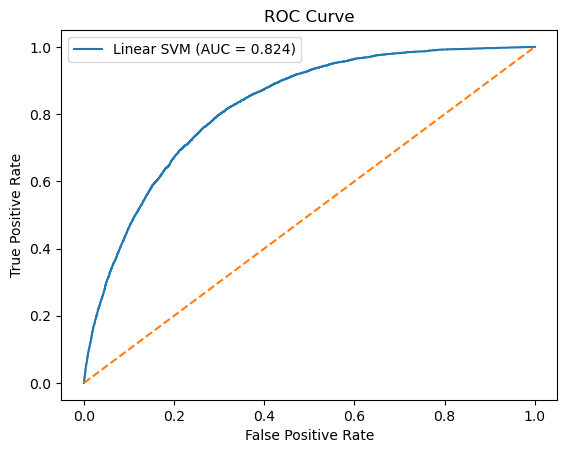

In [22]:
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

y_scores = svm.decision_function(X_test)

fpr, tpr, _ = roc_curve(y_test, y_scores)
auc_score = roc_auc_score(y_test, y_scores)

plt.figure()
plt.plot(fpr, tpr, label=f"Linear SVM (AUC = {auc_score:.3f})")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

In [23]:
import numpy as np

print("Number predicted as no diabetes (0):", np.sum(y_pred == 0))
print("Number predicted as diabetes (1):", np.sum(y_pred == 1))

Number predicted as no diabetes (0): 24428
Number predicted as diabetes (1): 12930


In [24]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, zero_division=0)
recall = recall_score(y_test, y_pred, zero_division=0)
f1 = f1_score(y_test, y_pred, zero_division=0)
auc_score = roc_auc_score(y_test, y_scores)

print("Accuracy :", round(accuracy, 4))
print("Precision:", round(precision, 4))
print("Recall   :", round(recall, 4))
print("F1-score :", round(f1, 4))
print("ROC AUC  :", round(auc_score, 4))

Accuracy : 0.7307
Precision: 0.3159
Recall   : 0.7705
F1-score : 0.4481
ROC AUC  : 0.824


In [25]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

print("Confusion Matrix:")
print(cm)

Confusion Matrix:
[[23211  8845]
 [ 1217  4085]]


In [26]:
from sklearn.model_selection import StratifiedKFold, RandomizedSearchCV, cross_val_score
#from hyperopt import tpe, STATUS_OK, Trials, hp, fmin, STATUS_OK, space_eval

In [30]:
C_range = np.logspace(-3, 2, 10)
print(f"The list of values for C are {C_range}")


The list of values for C are [1.00000000e-03 3.59381366e-03 1.29154967e-02 4.64158883e-02
 1.66810054e-01 5.99484250e-01 2.15443469e+00 7.74263683e+00
 2.78255940e+01 1.00000000e+02]


In [29]:
param_grid = {
    "C": C_range,
    "loss": ["hinge", "squared_hinge"],
    "penalty": ["l2"],
    "max_iter": [2000, 5000, 10000]
}
scoring = 'roc_auc'
kfold = StratifiedKFold(n_splits=3, shuffle=True, random_state=0)
random_search = RandomizedSearchCV(estimator=svm,
                                   param_distributions=param_grid,
                                   n_iter=10,
                                   scoring=scoring,
                                   refit='roc_auc',
                                   n_jobs=-1,
                                   cv=kfold,
                                   verbose=0)
random_result = random_search.fit(X_train, y_train)
random_result

RandomizedSearchCV(cv=StratifiedKFold(n_splits=3, random_state=0, shuffle=True),
                   estimator=LinearSVC(class_weight='balanced', max_iter=5000,
                                       random_state=42),
                   n_jobs=-1,
                   param_distributions={'C': array([1.00000000e-03, 3.59381366e-03, 1.29154967e-02, 4.64158883e-02,
       1.66810054e-01, 5.99484250e-01, 2.15443469e+00, 7.74263683e+00,
       2.78255940e+01, 1.00000000e+02]),
                                        'loss': ['hinge', 'squared_hinge'],
                                        'max_iter': [2000, 5000, 10000],
                                        'penalty': ['l2']},
                   refit='roc_auc', scoring='roc_auc')

In [40]:
print(f"The best ROC AUC score for the training dataset is {random_result.best_score_:.4f}")
print(f"The best hyperparameters are {random_result.best_params_}")
print(f"The best ROC AUC score for the testing dataset is {random_search.score(X_test, y_test):.4f}")

The best ROC AUC score for the training dataset is 0.8345
The best hyperparameters are {'penalty': 'l2', 'max_iter': 10000, 'loss': 'squared_hinge', 'C': 7.742636826811277}
The best ROC AUC score for the testing dataset is 0.8240


Text(0.5, 1.0, 'Linear SVM Metric Results')

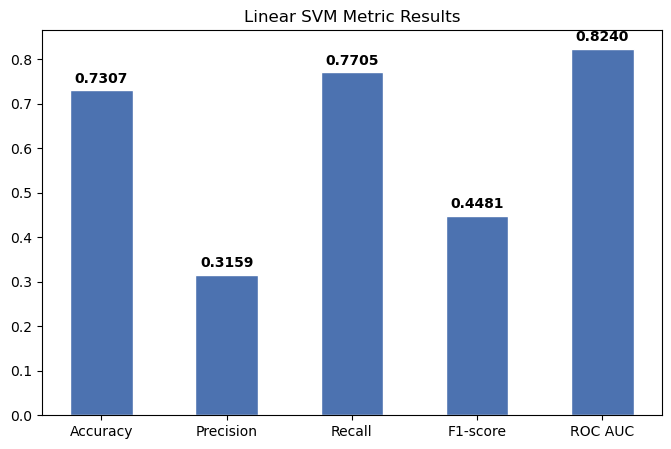

In [32]:
data = {
    "Metric": ["Accuracy", "Precision", "Recall", "F1-score", "ROC AUC"],
    "Score":  [round(accuracy, 4),    round(precision, 4),      round(recall, 4),   round(f1, 4),     round(auc_score, 4)]
}

df = pd.DataFrame(data)

fig, ax = plt.subplots(figsize=(8, 5))

bars = ax.bar(df["Metric"], df["Score"], color=["#4C72B0"], edgecolor="white", width=0.5)

for bar in bars:
    height = bar.get_height()
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        height + 0.01,
        f"{height:.4f}",
        ha="center", va="bottom", fontsize=10, fontweight="bold"
    )

ax.set_title("Linear SVM Metric Results")




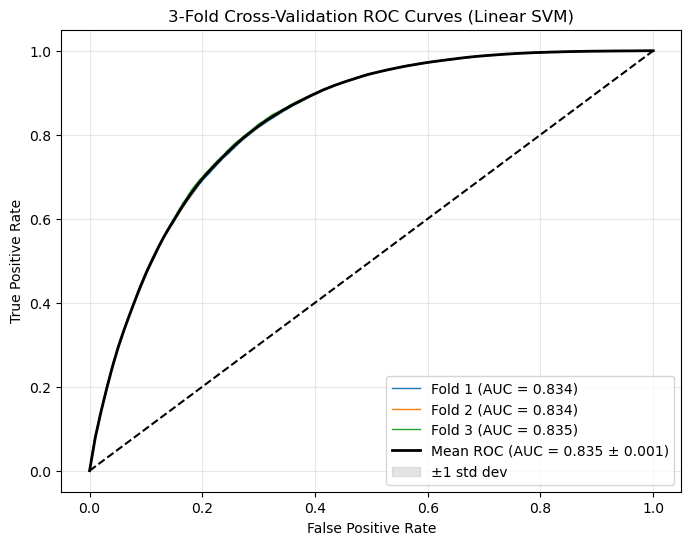

In [39]:

from sklearn.metrics import roc_curve, auc
from sklearn.model_selection import StratifiedKFold
from sklearn.base import clone

cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=0)

tprs = []
aucs = []
mean_fpr = np.linspace(0, 1, 100)

plt.figure(figsize=(8, 6))

for i, (train_idx, test_idx) in enumerate(cv.split(X_train, y_train)):
    
    model = clone(svm)
    model.fit(X_train[train_idx], y_train[train_idx])

    # decision scores (important for SVM)
    y_score = model.decision_function(X_train[test_idx])

    fpr, tpr, _ = roc_curve(y_train[test_idx], y_score)
    roc_auc = auc(fpr, tpr)

    plt.plot(fpr, tpr, lw=1, label=f'Fold {i+1} (AUC = {roc_auc:.3f})')

    # interpolate for mean curve
    interp_tpr = np.interp(mean_fpr, fpr, tpr)
    interp_tpr[0] = 0.0
    tprs.append(interp_tpr)
    aucs.append(roc_auc)

# mean ROC
mean_tpr = np.mean(tprs, axis=0)
mean_tpr[-1] = 1.0
mean_auc = np.mean(aucs)
std_auc = np.std(aucs)

plt.plot(mean_fpr, mean_tpr,
         color='black',
         label=f'Mean ROC (AUC = {mean_auc:.3f} ± {std_auc:.3f})',
         lw=2)

# std band
std_tpr = np.std(tprs, axis=0)
plt.fill_between(mean_fpr,
                 mean_tpr - std_tpr,
                 mean_tpr + std_tpr,
                 color='grey',
                 alpha=0.2,
                 label='±1 std dev')

plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('3-Fold Cross-Validation ROC Curves (Linear SVM)')
plt.legend()
plt.grid(alpha=0.3)
plt.show()